<div class="alert alert-success"><h1>Land cover classification</h1></div>

In [48]:
import ee
import geemap
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import numpy as np

sns.set_theme(style="whitegrid")

In [2]:
ee.Authenticate()

True

In [3]:
ee.Initialize(project = "ee-leviekytz")

In [4]:
import geemap

### Working with GEE
  
- Obtaining the mombasa shapefile and visualizing the shapefile

In [34]:
Map = geemap.Map() 
gaul = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2")
mombasa = gaul.filter(ee.Filter.eq("ADM2_NAME","Mombasa"))
roi = mombasa.geometry()
Map.centerObject(mombasa, 11)
Map.addLayer(mombasa,{},'Mombasa')

- Loading the sentinel 2 imagery

In [21]:
sentinel = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
s2 = (sentinel.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',40))
      .filterBounds(roi)
      .filterDate('2025-01-01', '2025-12-31'))
s2_clean = s2.median().clip(roi)
ml_image=  s2_clean.select(['B2','B3','B4','B8'])

visparams = {
    'bands': ['B4','B3','B2'],
    'min': 0,
    'max': 3000
}

Map.addLayer(s2_clean,visparams,'Mombasa sentinel')
Map


Map(bottom=4288561.0, center=[-4.028872765851165, 39.67497825622559], controls=(WidgetControl(options=['positi…

In [7]:
#Extracting water freatures
water_features = ee.FeatureCollection(Map.draw_features)

#Creating a function to store the different landc covers
def assign_water_class(feature):
    return feature.set('landcover', 0)

#Apply the class to the drawing feature
water_training = water_features.map(assign_water_class)
print("water_training_data captured!")

water_training_data captured!


In [8]:
#Extracting built-up areas
builtup_features = ee.FeatureCollection(Map.draw_features)

#Creating a function for built-up areas
def assign_builtup_class(feature):
    return feature.set('landcover', 1)

#Applying the class to the drawing feature
builtup_training=  builtup_features.map(assign_builtup_class)
print("Built up training data captured")

Built up training data captured


In [9]:
#Extracting vegetation
vegetation_features = ee.FeatureCollection(Map.draw_features)

#Creating a function for vegetation
def assign_vegetation_class(feature):
    return feature.set('landcover', 2)

#Assign the class to the drawing feature
vegetation_training = vegetation_features.map(assign_vegetation_class)
print("vegetation training data captured!")

vegetation training data captured!


In [10]:
#Extracting bareground
bareground_features = ee.FeatureCollection(Map.draw_features)

#Creating a function for baregroung
def assign_bareground_class(feature):
    return feature.set('landcover', 3)

#Assign the class to the drawing feature
bareground_training = bareground_features.map(assign_bareground_class)
print("bareground training data captured!")

bareground training data captured!


In [11]:
#Merging the training data
final_training_data=  water_training.merge(builtup_training).merge(vegetation_training).merge(bareground_training)
print("Total training polygons",final_training_data.size().getInfo())

Total training polygons 67


### Exporting to my local pc

In [14]:
output_file = "mombasa_training.shp"

#Export the merged feature collection to a shapefile
geemap.ee_export_vector(final_training_data, filename = output_file)
print(f"Sucessfully saved to {output_file}")

Generating URL ...
Please wait ...
Data downloaded to d:\gis_programming\my_projects\LULC\mombasa_training.shp
Sucessfully saved to mombasa_training.shp


### Exporting to GEE Assets

In [15]:
#Defining the asset path
asset_path = "projects/ee-leviekytz/assets/mombasa_training_data"

#Configure the export task
export_task=  ee.batch.Export.table.toAsset(
    collection= final_training_data,
    description = "Export mombasa training data",
    assetId= asset_path
)

#Start the task
export_task.start()
print("Export started! Check the 'Tasks' tab in the GEE Code Editor to see the progress.")


Export started! Check the 'Tasks' tab in the GEE Code Editor to see the progress.


### Sampling pixels using sampleRegions 

In [23]:
sampled_features = ml_image.sampleRegions(
    collection= final_training_data,
    properties= ['landcover'],
    scale= 10,
    tileScale= 16
)

#Converting earth engine object to a dataframe
df_training = geemap.ee_to_df(sampled_features)

#Vewing the dataframe head
print(df_training.head())


      B2      B3     B4      B8  landcover
0  777.0  1026.0  934.0  1560.0          0
1  764.0  1044.0  952.0  1614.0          0
2  756.0  1008.0  966.0  1594.0          0
3  791.0  1042.0  972.0  1560.0          0
4  778.0  1050.0  968.0  1558.0          0


### Exploatory Data Analysis

**Dataset health-check**

In [32]:
print("The shape of the dataset is", df_training.shape)
print('-' * 50)
print(df_training.info())
print('-' * 50)

#Checking for missing data
print("Missing values:\n", df_training.isnull().sum())

The shape of the dataset is (1030218, 5)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030218 entries, 0 to 1030217
Data columns (total 5 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   B2         1030218 non-null  float64
 1   B3         1030218 non-null  float64
 2   B4         1030218 non-null  float64
 3   B8         1030218 non-null  float64
 4   landcover  1030218 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 39.3 MB
None
--------------------------------------------------
Missing values:
 B2           0
B3           0
B4           0
B8           0
landcover    0
dtype: int64


**Class distribution**

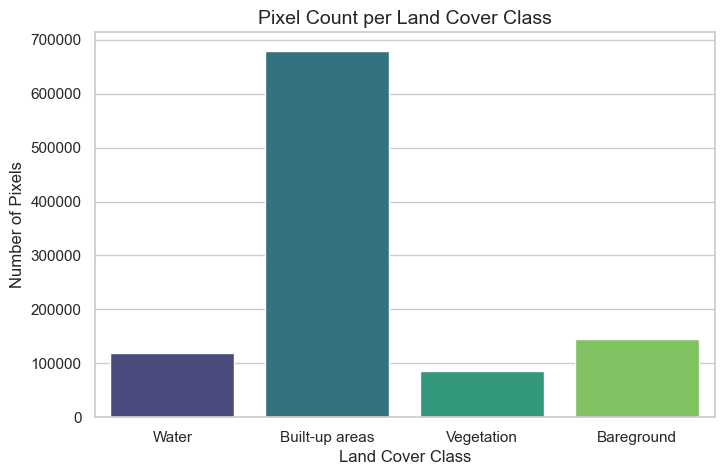

In [35]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_training, x='landcover', palette='viridis')
plt.title('Pixel Count per Land Cover Class', fontsize=14)
plt.xlabel('Land Cover Class', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Water', 'Built-up areas', 'Vegetation','Bareground'])
plt.show()

### Spectral separability

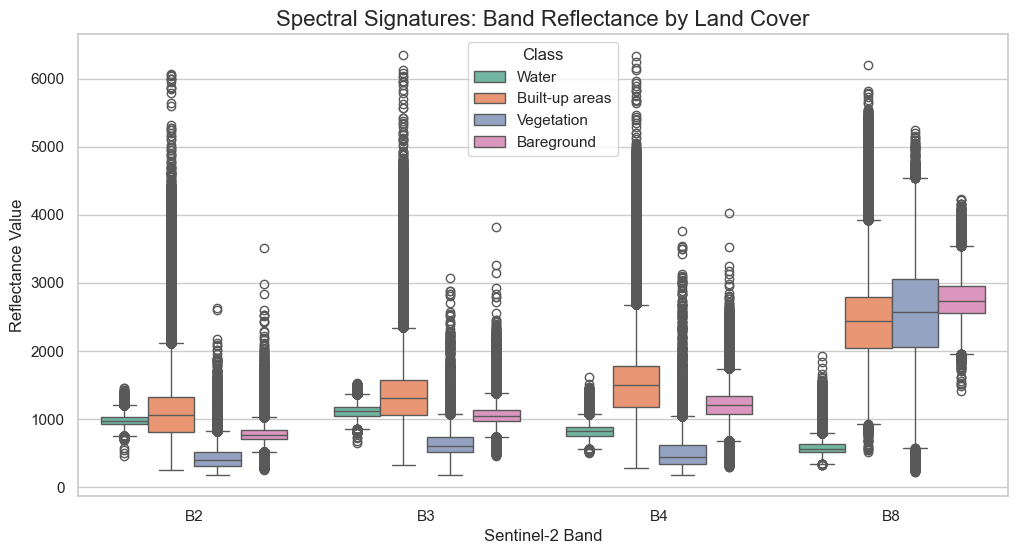

In [37]:
# Keep only our bands and target variable
bands = ['B2', 'B3', 'B4', 'B8']
df_melted = df_training.melt(id_vars='landcover', value_vars=bands, 
                             var_name='Band', value_name='Reflectance')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Band', y='Reflectance', hue='landcover', palette='Set2')
plt.title('Spectral Signatures: Band Reflectance by Land Cover', fontsize=16)
plt.xlabel('Sentinel-2 Band', fontsize=12)
plt.ylabel('Reflectance Value', fontsize=12)

# Update the legend for readability
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, labels=['Water', 'Built-up areas', 'Vegetation','Bareground'], title='Class')
plt.show()

### Downsampling for the built-up areas
- Balances the dataset by downsampling

In [38]:
# 1. Find the exact number of pixels in your smallest class
min_class_size = df_training['landcover'].value_counts().min()
print(f"Balancing all classes to exactly {min_class_size} pixels each...")

# 2. Group by landcover and randomly sample 'min_class_size' rows from each class
df_balanced = df_training.groupby('landcover').apply(
    lambda x: x.sample(n=min_class_size, random_state=42)
).reset_index(drop=True)

# 3. Verify the new, perfectly balanced distribution
print("-" * 30)
print(df_balanced['landcover'].value_counts())

Balancing all classes to exactly 85795 pixels each...
------------------------------
landcover
0    85795
1    85795
2    85795
3    85795
Name: count, dtype: int64


### Training the model

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [40]:
# Defining the X (features) and y (targets)
X = df_balanced.drop(columns = ['landcover'])
y = df_balanced['landcover']

#Splitting data
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = .2, random_state = 42)
print(f"Training on {len(X_train)} pixels, testing on {len(X_test)} pixels...\n")

Training on 274544 pixels, testing on 68636 pixels...



In [42]:
#Building the model
rfc = RandomForestClassifier(n_estimators = 100, random_state = 42)

rfc.fit(X_train, y_train)

#Prediction on hidden dataset
y_pred = rfc.predict(X_test)

#Evaluation of the results
print("=== MODEL ACCURACY ===")
print(f"Overall accuracy {accuracy_score(y_test, y_pred) * 100: .2f} % \n")

print("===CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names= ['Water(0)','Vegetation(1)','Built-up areas(2)','Bareground(3)']))

=== MODEL ACCURACY ===
Overall accuracy  88.99 % 

===CLASSIFICATION REPORT ===
                   precision    recall  f1-score   support

         Water(0)       1.00      1.00      1.00     17160
    Vegetation(1)       0.85      0.78      0.82     17186
Built-up areas(2)       0.92      0.90      0.91     17132
    Bareground(3)       0.79      0.88      0.83     17158

         accuracy                           0.89     68636
        macro avg       0.89      0.89      0.89     68636
     weighted avg       0.89      0.89      0.89     68636



### Exporting my geoTIF image to my google drive

In [44]:
# 1. Configure the batch export task to Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=ml_image,                   
    description='Mombasa_Sentinel_10m', 
    folder='GEE',       
    fileNamePrefix='sentinel_training_data',
    region=roi,                         
    scale=10,                          
    maxPixels=1e13                     
)

# 2. Start the background task
export_task.start()

print("Export started! Go to the 'Tasks' tab in the GEE Code Editor to watch it process.")

Export started! Go to the 'Tasks' tab in the GEE Code Editor to watch it process.


In [49]:
image_path = 'G:/My Drive/GEE/sentinel_training_data.tif'

print("Reading satellite data from google drive")

with rasterio.open(image_path) as src:
    b2 = src.read(1)
    b3 = src.read(2)
    b4 = src.read(3)
    b8 = src.read(4)

    #Saving the spatial meta, to ensure output map aligns perfectly with msa
    meta = src.meta

    #Capture height and width for reshaping later
    height, width = b2.shape

#Flattennig 2D arrays to 1D tabular datafor 
df_full=pd.DataFrame({
    'B2': b2.flatten(),
    'B3': b3.flatten(),
    'B4': b4.flatten(),
    'B8': b8.flatten()
})

#Mask out NoData background pixels 
valid_pixel_mask = (df_full['B2'] > 0)

#Creating an empty array to hold our prediction
prediction_1d = np.full(len(df_full),255,dtype ='uint8')

#Run the Random Forest predictions ONLY on the valid pixels
print("Running ML predictions across the city... this might take a moment!")
prediction_1d[valid_pixel_mask] = rfc.predict(df_full[valid_pixel_mask])

#Reshape the 1D list back into a 2D spatial image
predicted_map_2d = prediction_1d.reshape(height, width)

# 7. Update the metadata for our new single-band classification image
meta.update(
    count=1,           # We are only exporting 1 band (the predicted classes)
    dtype='uint8',     # Unsigned 8-bit integer is perfect for simple class numbers (0, 1, 2)
    nodata=255         # Tell the software that 255 means "ignore this pixel"
)

#Export the final mapped predictions to your hard drive
output_path = 'mombasa_predicted_landcover.tif'

with rasterio.open(output_path, 'w', **meta) as dst:
    dst.write(predicted_map_2d, 1)

print(f"Success! Final predictive map saved to: {output_path}")


Reading satellite data from google drive
Running ML predictions across the city... this might take a moment!
Success! Final predictive map saved to: mombasa_predicted_landcover.tif
